# Plotting for Sleep-consolidated Learning

## Setup

In [1]:
# !pip install seaborn matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
import pandas as pd
import scipy
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from scipy.stats import pearsonr

### Plotting setup

In [2]:
config_params = ['config/n_phases',
 'config/replay_ratio',
 'config/max_seq_length',
 'config/n_augmentations',
 'config/sleep_max_steps',
 'config/wake_block_steps',
 'config/contextualize_sleep',
 'config/sleep_loss_threshold']

config_params_formatted = ['N Phases',
 'Replay Ratio',
 'Max Sequence Length',
 'N Augs',
 'Sleep Steps',
 'Wake Steps',
 'Contextualize Sleep',
 'Sleep Loss Threshold']

config_format_map = dict(zip(config_params, config_params_formatted))
config_format_map.update(dict(zip(config_params_formatted, config_params)))

correlation_cmap = {
    "Pos": "#EC7272",
    "Neg": "#BCD9A2"
}

model_cmap = {
    "Baseline": "#98a0a2",
    "Baseline-like": "#BFC9CC",
    "Sleep": "#FFA95A"
}

# BabyLM Eval

babylm_tasks = [
    'blimp',
    'wug_adj',
    'wug_past',
    'entity_tracking',
    'overall'
]

babylm_tasks_formatted = [
    'BLiMP',
    'Wugs: Adj.',
    'Wugs: Past',
    'Entity Tracking',
    'Overall'
]

## Sweeps

### Read Wandb sweep data

In [98]:
api = wandb.Api()
wandb_entity = "lemn-lab"
wandb_project = "sleep-consolidated-learning"
wandb_sweep_ids = ["1eq32rsz", "360fgz0o"]
sweep_paths=[f"{wandb_entity}/{wandb_project}/{sweep_id}" for sweep_id in wandb_sweep_ids]

In [99]:

results = []
for sweep_id in wandb_sweep_ids:
    runs = api.runs(f"{wandb_entity}/{wandb_project}", filters={"sweep": sweep_id})
    for run in runs:
        result = dict(run.summary)
        sleep_configs = {f"config/{key}":value for key, value in run.config['sleep_mechanism'].items()}
        result.update(sleep_configs)
        result.update({
            'id': run.id
        })
        results.append(result)
results = pd.DataFrame(results)
results = results.set_index('id')
results.shape

(48, 43)

In [100]:
eval_metrics = [col for col in results.columns if "eval" in col]
train_metrics = [col for col in results.columns if "train" in col]
# config_params = [col for col in results.columns if "config" in col]
config_params = [
    "config/replay_ratio",
    "config/sleep_max_steps",
    "config/n_phases",
    "config/contextualize_sleep"
]
eval_metric = 'eval/best_perplexity_mean'

In [101]:
config_params

['config/replay_ratio',
 'config/sleep_max_steps',
 'config/n_phases',
 'config/contextualize_sleep']

### Check importance and correlation of parameters

In [102]:
data = results[config_params + [eval_metric]]
filter_unchanged_params = lambda col: data[col].value_counts().shape[0] > 1
data[config_params] = StandardScaler().fit_transform(data[config_params])
# Filter out unchanged parameters and NaNs
params_of_interest = list(filter(filter_unchanged_params, config_params))
data = data.loc[:, params_of_interest + [eval_metric]]
data = data[data.isna().sum(axis=1) == 0]
X = data[params_of_interest]
y = data[[eval_metric]]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [103]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_hat = linear_model.predict(X_test)
mse(y_test, y_hat)

471065.5412505005

In [104]:
rf_model = RandomForestRegressor(n_estimators=1000)
rf_model.fit(X_train, y_train)
y_hat = rf_model.predict(X_test)
mse(y_test, y_hat)

/Users/tzhang04/Desktop/BabyLM/sleep/sleep-plotting/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


1326.1151313986134

In [105]:
correlations = []
for param in params_of_interest:
    corr = pearsonr(data[param], data[eval_metric])
    correlations.append(corr.statistic)

In [106]:
bootstrap_results = []
n_bootstraps = 100
for _ in range(n_bootstraps):
    bootstrapped_data = data.sample(data.shape[0], replace=True)
    
    # rf feature importances
    X = bootstrapped_data[params_of_interest]
    y = bootstrapped_data[[eval_metric]].to_numpy().ravel()
    rf_model = RandomForestRegressor(n_estimators=1000)
    rf_model.fit(X, y)
    feature_importances = dict(zip(params_of_interest, rf_model.feature_importances_))
    for param in params_of_interest:
        # correlation
        corr = pearsonr(bootstrapped_data[param], bootstrapped_data[eval_metric])
        result = {
            "Parameter": config_format_map[param],
            "Parameter Importance": feature_importances[param],
            "Correlation": corr[0]
        }
        bootstrap_results.append(result)
bootstrap_results = pd.DataFrame(bootstrap_results)
bootstrap_results

,Parameter,Parameter Importance,Correlation
0,Replay Ratio,0.116176,0.318709
1,Sleep Steps,0.165754,0.134352
2,N Phases,0.712648,0.084111
3,Contextualize Sleep,0.005422,0.080412
4,Replay Ratio,0.117314,-0.253651
...,...,...,...
395,Contextualize Sleep,0.003869,0.215977
396,Replay Ratio,0.154746,-0.005371
397,Sleep Steps,0.110252,0.133084
398,N Phases,0.734347,0.464955


''

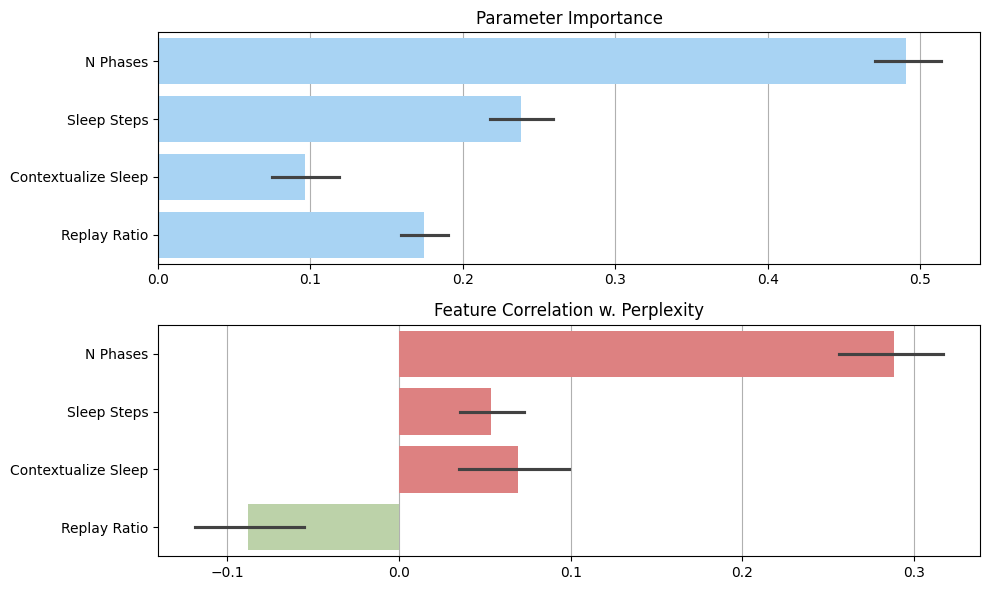

In [107]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharey=True)
formatted_params = [config_format_map[param] for param in params_of_interest]
bootstrap_results = bootstrap_results.sort_values("Parameter")
# importance
axs[0].grid(axis='x', zorder=0)
sns.barplot(bootstrap_results.sort_values("Parameter Importance", ascending=False), y='Parameter', x='Parameter Importance', ax=axs[0],
            color="#9CD5FF", zorder=2)
axs[0].set_title("Parameter Importance")
axs[0].set_xlabel("")
axs[0].set_ylabel("")
# axs[0].set_xlim(0, 1)

# correlation
corr_colors = [correlation_cmap['Pos'] if corr > 0 else correlation_cmap['Neg']
               for corr in bootstrap_results.groupby('Parameter')['Correlation'].mean()]
sns.barplot(bootstrap_results, y='Parameter', x='Correlation', hue='Parameter', ax=axs[1],
            palette=corr_colors, legend=False, zorder=2)
axs[1].set_title("Feature Correlation w. Perplexity")
# axs[1].set_xlabel("Correlation with Perplexity")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
axs[1].grid(axis='x')
# axs[1].set_xlim(-0.25, 0.25)

plt.tight_layout()
plt.savefig("plots/sweep_para_results.png",
            dpi=300, bbox_inches='tight',
            transparent=True)
;

### Perplexity Heatmap

In [108]:
results.groupby(["config/n_phases", "config/replay_ratio"])["eval/best_perplexity_mean"].mean().reset_index()

,config/n_phases,config/replay_ratio,eval/best_perplexity_mean
0,1,0.2,897.855489
1,1,0.6,897.986938
2,1,1.0,897.986938
3,50,0.2,330.379410
4,50,0.6,163.801760
5,50,1.0,412.153776
6,100,0.2,2529.112720
7,100,0.6,990.011749
8,100,1.0,1957.058553


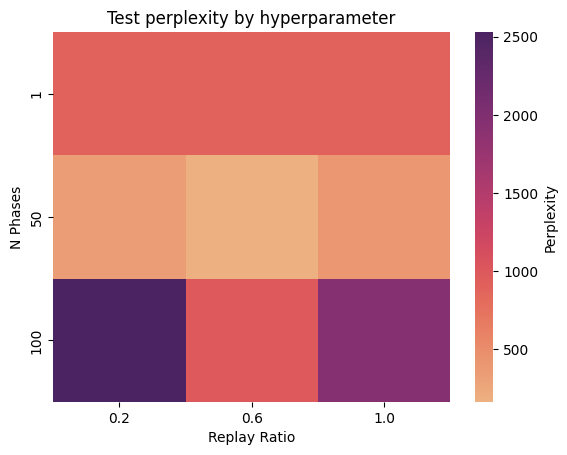

In [109]:
pivot=results.pivot_table(values="eval/best_perplexity_mean",
                index="config/n_phases",
                columns="config/replay_ratio",
                aggfunc=np.mean)
sns.heatmap(pivot, cmap='flare',
            cbar_kws={'label': 'Perplexity'})
plt.title("Test perplexity by hyperparameter")
plt.ylabel("N Phases")
plt.xlabel("Replay Ratio")
plt.savefig("plots/ppl_heatmap.png", dpi=300, bbox_inches='tight')

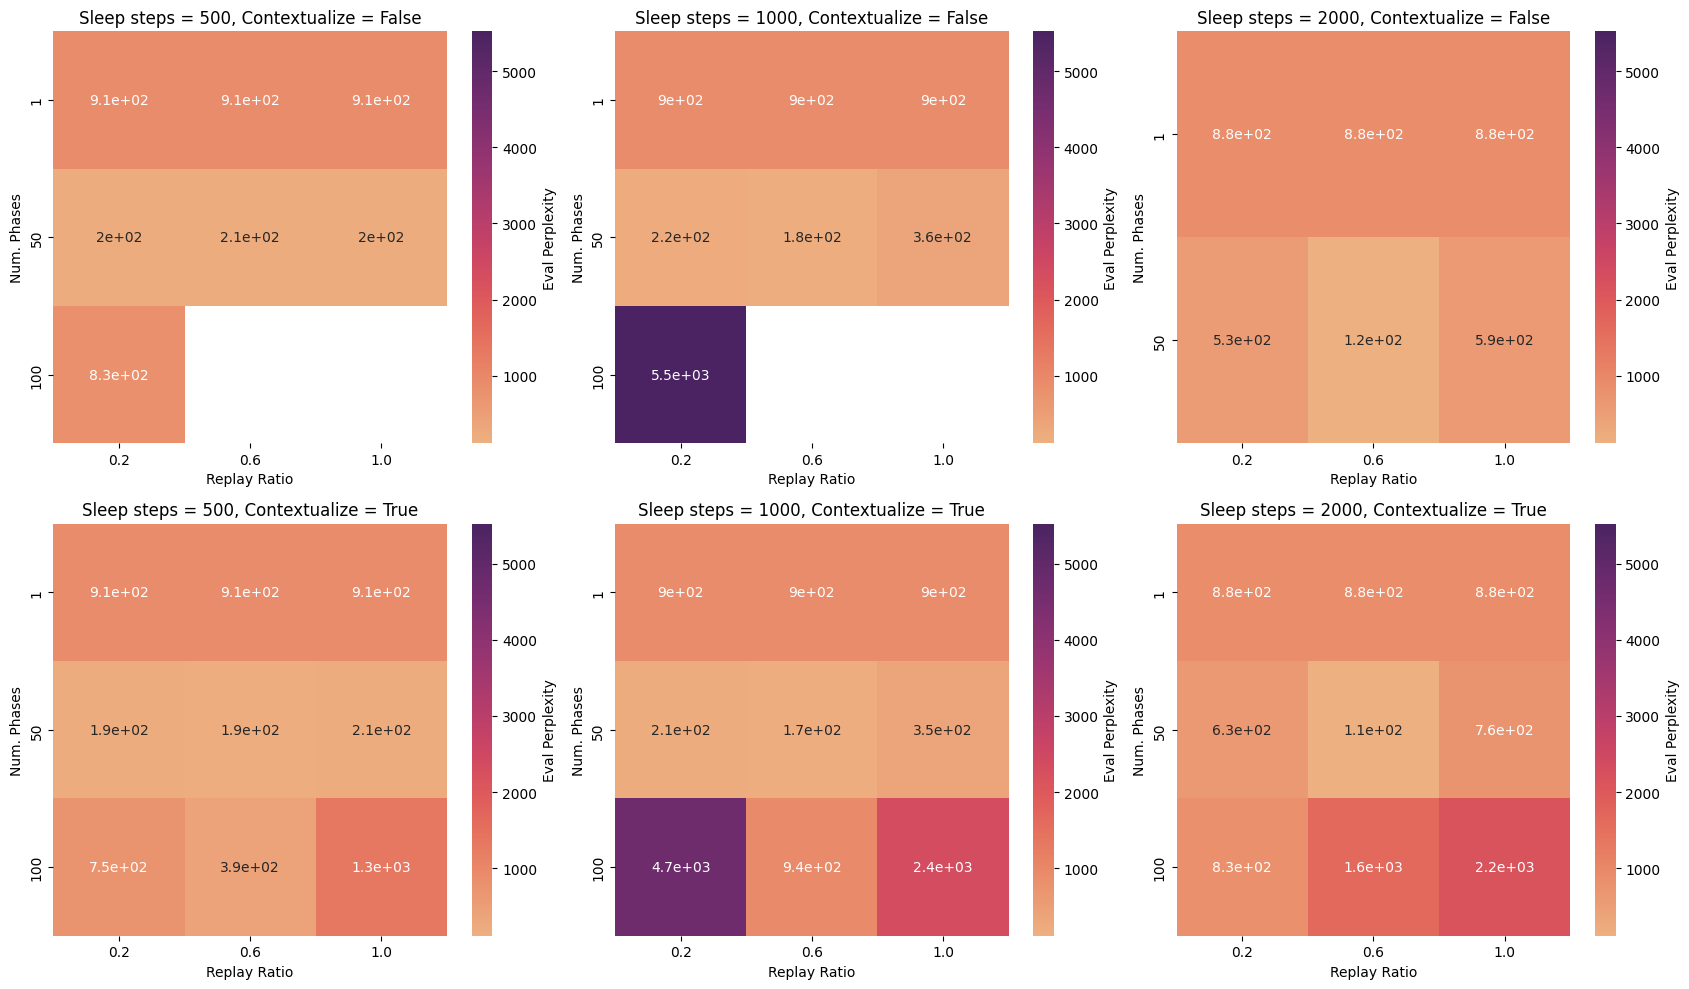

In [111]:
fig, axs = plt.subplots(2, 3, figsize=(17, 10))
max_ppl = results['eval/best_perplexity_mean'].max()
min_ppl = results['eval/best_perplexity_mean'].min()
for row, context in zip(axs, [False, True]):
    for ax, steps in zip(row, results['config/sleep_max_steps'].unique()):
        pivot = (results[(results['config/sleep_max_steps'] == steps)
                         & (results['config/contextualize_sleep']==context)]
                .pivot_table(values="eval/best_perplexity_mean",
                    index="config/n_phases",
                    columns="config/replay_ratio",
                    aggfunc=np.mean))
        sns.heatmap(pivot, ax=ax, vmin=min_ppl, vmax=max_ppl, cmap='flare',
                    cbar_kws={'label': 'Eval Perplexity'}, annot=True)
        ax.set_title(f"Sleep steps = {steps}, Contextualize = {context}")
        ax.set_ylabel("Num. Phases")
        ax.set_xlabel("Replay Ratio")
        plt.tight_layout()
plt.savefig("plots/gridsearch_heatmap.png", dpi=300, bbox_inches='tight')

### BabyLM Evals

In [16]:
eval_metrics

['eval/before_SLEEP_perplexity_max',
 'eval/before_SLEEP_perplexity_mean',
 'eval/before_SLEEP_perplexity_std',
 'eval/before_SLEEP_runtime',
 'eval/best_model_step',
 'eval/best_perplexity_max',
 'eval/best_perplexity_mean',
 'eval/best_perplexity_std',
 'eval/best_runtime',
 'eval/perplexity_max',
 'eval/perplexity_mean',
 'eval/perplexity_std',
 'eval/runtime',
 'eval/before_WAKE_perplexity_max',
 'eval/before_WAKE_perplexity_mean',
 'eval/before_WAKE_perplexity_std',
 'eval/before_WAKE_runtime']

## Replay Experiment

In [24]:
random_run = api.run(f"{wandb_entity}/{wandb_project}/z61n2zkz")
weighted_run = api.run(f"{wandb_entity}/{wandb_project}/vj4c9fev")
strict_run = api.run(f"{wandb_entity}/{wandb_project}/hxuu5fxg")

In [25]:
random_run.summary

{'_runtime': 30808, '_step': 2126, '_timestamp': 1771861048.2346275, '_wandb': {'runtime': 30808}, 'eval/babylm_TEMPERATURE': 1, 'eval/babylm_adjunct_island': 45, 'eval/babylm_anaphor_agreement': 58.5, 'eval/babylm_anaphor_gender_agreement': 57, 'eval/babylm_anaphor_number_agreement': 60, 'eval/babylm_animate_subject_passive': 54, 'eval/babylm_animate_subject_trans': 72.5, 'eval/babylm_argument_structure': 52.14, 'eval/babylm_avg': 51.97030303030302, 'eval/babylm_binding': 57.86, 'eval/babylm_causative': 45, 'eval/babylm_complex_NP_island': 54.5, 'eval/babylm_control_raising': 53.9, 'eval/babylm_coordinate_structure_constraint_complex_left_branch': 31.5, 'eval/babylm_coordinate_structure_constraint_object_extraction': 62, 'eval/babylm_determiner_noun_agreement': 65.69, 'eval/babylm_determiner_noun_agreement_1': 60, 'eval/babylm_determiner_noun_agreement_2': 67.5, 'eval/babylm_determiner_noun_agreement_irregular_1': 64.5, 'eval/babylm_determiner_noun_agreement_irregular_2': 83, 'eval/ba

In [26]:
runs = [random_run, weighted_run, strict_run]
run_data=pd.DataFrame({
    "Run": ["Random", "Weighted", "Strict"],
    "Mean PPL": [run.summary['eval/best_perplexity_mean'] for run in runs],
    "Max PPL": [run.summary['eval/best_perplexity_max'] for run in runs],
    "STD PPL": [run.summary['eval/best_perplexity_std'] for run in runs],
    "BabyLM": [run.summary['eval/best_babylm_avg'] for run in runs],
})

''

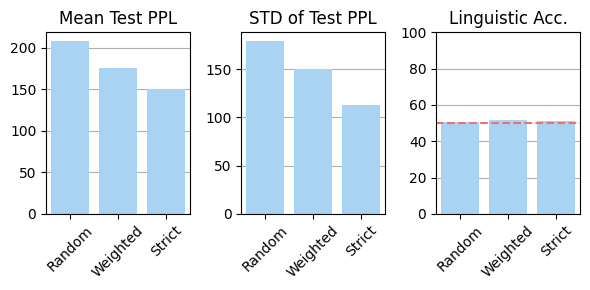

In [97]:
fig, axs = plt.subplots(1, 3, figsize=(6, 3), sharex=True)
# Mean PPL
axs[0].grid(axis='y', zorder=0)
sns.barplot(run_data, y='Mean PPL', x='Run', ax=axs[0],
            color="#9CD5FF", zorder=2)
axs[0].set_title("Mean Test PPL")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

# STD of PPL
axs[1].grid(axis='y', zorder=0)
sns.barplot(run_data, y='STD PPL', x='Run', ax=axs[1],
            color="#9CD5FF", zorder=2)
axs[1].set_title("STD of Test PPL")
axs[1].set_xlabel("")
axs[1].set_ylabel("")

# correlation
sns.barplot(run_data, y='BabyLM', x='Run', ax=axs[2],
            color="#9CD5FF", zorder=2)
axs[2].set_title("Linguistic Acc.")
axs[2].set_xlabel("")
axs[2].set_ylabel("")
axs[2].grid(axis='y')
axs[2].set_ylim(0, 100)
axs[2].axhline(y=50, color=correlation_cmap['Pos'], linestyle="--")

for ax in axs:
    ax.set_xticks(ticks=run_data['Run'], labels=run_data['Run'], rotation=45)

plt.tight_layout()
plt.savefig("plots/replay_strat_results.png",
            dpi=300, bbox_inches='tight',
            transparent=True)
;

## Graphing Training Loss

In [28]:
eval_metrics

['eval/before_SLEEP_perplexity_max',
 'eval/before_SLEEP_perplexity_mean',
 'eval/before_SLEEP_perplexity_std',
 'eval/before_SLEEP_runtime',
 'eval/best_model_step',
 'eval/best_perplexity_max',
 'eval/best_perplexity_mean',
 'eval/best_perplexity_std',
 'eval/best_runtime',
 'eval/perplexity_max',
 'eval/perplexity_mean',
 'eval/perplexity_std',
 'eval/runtime',
 'eval/before_WAKE_perplexity_max',
 'eval/before_WAKE_perplexity_mean',
 'eval/before_WAKE_perplexity_std',
 'eval/before_WAKE_runtime']

In [29]:
best_run_id = results.sort_values('eval/best_perplexity_mean', ascending=True).index[0]
best_run_id

'ivws1mnn'

In [30]:
runs = api.runs(f"{wandb_entity}/{wandb_project}", filters={"sweep": wandb_sweep_id})
best_run = [run for run in runs if run.id == best_run_id][0]

NameError: name 'wandb_sweep_id' is not defined

In [ ]:
results.loc[[best_run_id]]

,_runtime,_step,_timestamp,_wandb,eval/before_SLEEP_perplexity_max,eval/before_SLEEP_perplexity_mean,eval/before_SLEEP_perplexity_std,eval/before_SLEEP_runtime,eval/before_WAKE_perplexity_max,eval/before_WAKE_perplexity_mean,...,train_samples_per_second,train_steps_per_second,config/n_phases,config/replay_ratio,config/max_seq_length,config/n_augmentations,config/sleep_max_steps,config/wake_block_steps,config/contextualize_sleep,config/sleep_loss_threshold
id,,,,,,,,,,,,,,,,,,,,,
egsiqgxx,4386.475343,2167,1.771677e+09,{'runtime': 4387},6578.293457,667.283386,899.225586,7.9966,5378.240234,738.875916,...,391.767,6.121,50,0.56139,128,40,500,9999999,True,0.5


In [ ]:
keys = [
    'train/loss_mlm',
    'train/loss_mlm_SLEEP',
    'train/loss_mlm_WAKE',
    'eval/before_SLEEP_perplexity_mean',
    'eval/before_WAKE_perplexity_mean'
]
histories = []
for key in keys:
    hist = best_run.history(keys=[key])
    histories.append(hist)
best_run_history = histories[0]
for hist in histories[1:]:
    best_run_history = best_run_history.merge(hist, on='_step', how='outer')
best_run_history['train_PPL'] = (best_run_history['eval/before_SLEEP_perplexity_mean'].fillna(0) 
                                 + best_run_history['eval/before_WAKE_perplexity_mean'].fillna(0))

In [ ]:
phase = []
curr_phase = "WAKE"
for ppl in best_run_history['train_PPL']:
    phase.append(curr_phase)
    if ppl != 0:
        curr_phase = "SLEEP" if curr_phase == "WAKE" else "WAKE"
best_run_history['phase'] = phase
# best_run_history['train/loss_mlm_SLEEP'] = best_run_history['train/loss_mlm_SLEEP'].fillna(np.inf)
# best_run_history['train/loss_mlm_WAKE'] = best_run_history['train/loss_mlm_WAKE'].fillna(np.inf)

In [ ]:
best_run_history.head()

,_step,train/loss_mlm,train/loss_mlm_SLEEP,train/loss_mlm_WAKE,eval/before_SLEEP_perplexity_mean,eval/before_WAKE_perplexity_mean,train_PPL,phase
0,2,1.301908,NaN,1.301908,NaN,NaN,0.000000,WAKE
1,4,1.284770,NaN,1.284770,NaN,NaN,0.000000,WAKE
2,5,NaN,NaN,NaN,8427.470703,NaN,8427.470703,WAKE
3,7,NaN,8.863770,NaN,NaN,NaN,0.000000,SLEEP
4,9,NaN,8.518527,NaN,NaN,NaN,0.000000,SLEEP


In [ ]:
ppl_changes_after_sleep = (
    best_run_history.loc[~best_run_history['eval/before_WAKE_perplexity_mean'].isna(),
                      'eval/before_WAKE_perplexity_mean'].reset_index(drop=True)
    - best_run_history.loc[~best_run_history['eval/before_SLEEP_perplexity_mean'].isna(),
                      'eval/before_SLEEP_perplexity_mean'].reset_index(drop=True)
 )

Text(0, 0.5, 'Eval Perplexity')

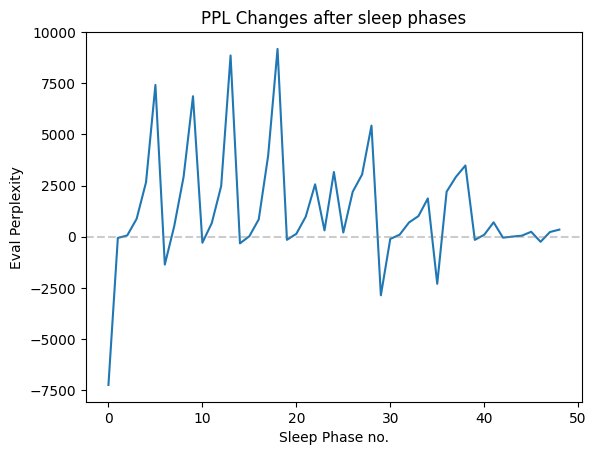

In [ ]:
sns.lineplot(ppl_changes_after_sleep)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
plt.title('PPL Changes after sleep phases')
plt.xlabel('Sleep Phase no.')
plt.ylabel('Eval Perplexity')

In [ ]:
ppl_changes_after_wake = (
    best_run_history.loc[~best_run_history['eval/before_SLEEP_perplexity_mean'].isna(),
                      'eval/before_SLEEP_perplexity_mean'].reset_index(drop=True).iloc[1:]
    - best_run_history.loc[~best_run_history['eval/before_WAKE_perplexity_mean'].isna(),
                      'eval/before_WAKE_perplexity_mean'].reset_index(drop=True)
 )

Text(0, 0.5, 'Eval Perplexity')

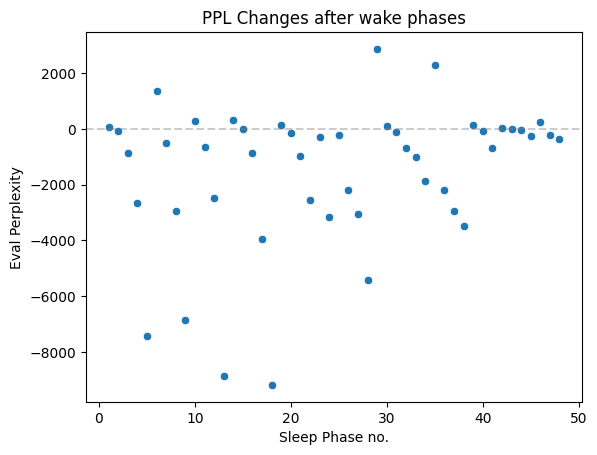

In [ ]:
sns.scatterplot(ppl_changes_after_wake)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
plt.title('PPL Changes after wake phases')
plt.xlabel('Sleep Phase no.')
plt.ylabel('Eval Perplexity')

In [ ]:
best_run_history.loc[best_run_history['train_PPL'] > 0]

,_step,train/loss_mlm,train/loss_mlm_SLEEP,train/loss_mlm_WAKE,eval/before_SLEEP_perplexity_mean,eval/before_WAKE_perplexity_mean,train_PPL,phase
2,5,NaN,NaN,NaN,8427.470703,NaN,8427.470703,WAKE
16,44,NaN,NaN,NaN,NaN,1182.765503,1182.765503,SLEEP
18,47,NaN,NaN,NaN,1188.276978,NaN,1188.276978,WAKE
28,88,NaN,NaN,NaN,NaN,1127.874634,1127.874634,SLEEP
30,91,NaN,NaN,NaN,1121.202881,NaN,1121.202881,WAKE
...,...,...,...,...,...,...,...,...
852,2040,NaN,NaN,NaN,150.265808,NaN,150.265808,WAKE
868,2079,NaN,NaN,NaN,NaN,380.601654,380.601654,SLEEP
871,2084,NaN,NaN,NaN,391.293213,NaN,391.293213,WAKE
888,2123,NaN,NaN,NaN,NaN,738.875916,738.875916,SLEEP


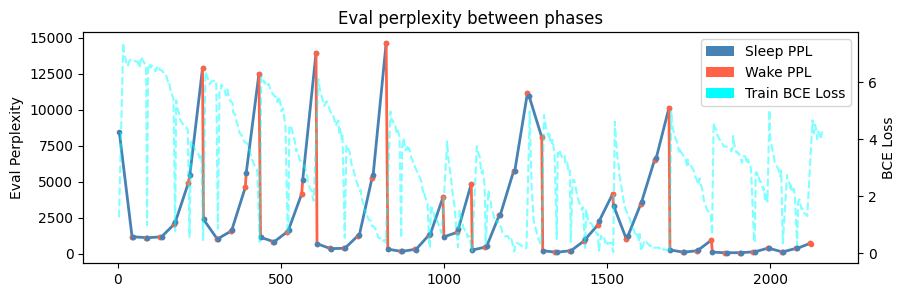

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 3))
data=best_run_history.loc[best_run_history['train_PPL'] > 0]
x=data['_step']
y=data['train_PPL']

# Define alternating colors
colors = ['steelblue', 'tomato']

# Plot each segment between consecutive points with alternating colors
for i in range(len(x) - 1):
    color = colors[i % len(colors)]
    ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=2, marker='.')
    
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[0], label='Sleep PPL'),
                   Patch(facecolor=colors[1], label='Wake PPL'),
                   Patch(facecolor='cyan', label='Train BCE Loss')
                ]

ax2 = ax.twinx()
sns.lineplot(best_run_history, x='_step', y='train/loss_mlm', ax=ax2, color='cyan', alpha=0.5, linestyle='--')
ax.legend(handles=legend_elements)
plt.title('Eval perplexity between phases')
plt.xlabel('Step #')
# plt.xlim(0, 300)
ax.set_ylabel('Eval Perplexity')
ax2.set_ylabel('BCE Loss')
fig.savefig("plots/ppl_phases", dpi=300, bbox_inches='tight')

Text(0, 0.5, 'MLM BCE Loss')

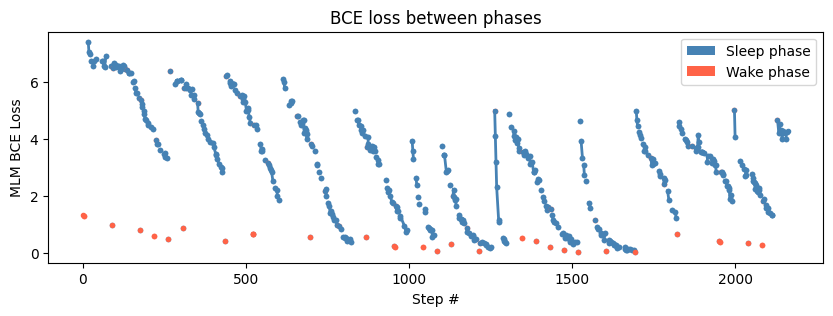

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 3))
data=best_run_history
x=data['_step']
y=data['train/loss_mlm']
phases = data['phase']

# Define alternating colors
colors = {'SLEEP': 'steelblue', 
          'WAKE': 'tomato'}

# Plot each segment between consecutive points with alternating colors
for i in range(len(x) - 1):
    color = colors[phases[i]]
    ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=2, marker='.')
    
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['SLEEP'], label='Sleep phase'),
                   Patch(facecolor=colors['WAKE'], label='Wake phase'),
                #    Patch(facecolor='cyan', label='Train Loss')
                   ]

# ax2 = ax.twinx()
# sns.lineplot(best_run_history, x='_step', y='train/loss_mlm', ax=ax2, color='cyan', alpha=0.5, linestyle='--')
ax.legend(handles=legend_elements)
plt.title('BCE loss between phases')
plt.xlabel('Step #')
ax.set_ylabel('MLM BCE Loss')
# ax2.set_ylabel('BCE Loss')
# fig.savefig("plots/ppl_phases", dpi=200, bbox_inches='tight')

In [40]:
# # !pip install plotly
# # import plotly
# # import plotly.graph_objects as go

# # Filter data
# data = best_run_history.loc[best_run_history['train_PPL'] > 0]
# x = data['_step'].values
# y = data['train_PPL'].values
# y2 = data['train/loss_mlm'].values

# colors = ['steelblue', 'tomato']

# fig = go.Figure()

# # Alternating segments for PPL
# for i in range(len(x) - 1):
#     color = colors[i % len(colors)]
#     name = 'Sleep PPL' if i % 2 == 0 else 'Wake PPL'
    
#     fig.add_trace(
#         go.Scatter(
#             x=x[i:i+2],
#             y=y[i:i+2],
#             mode='lines+markers',
#             line=dict(color=color, width=2),
#             marker=dict(size=6),
#             name=name,
#             legendgroup=name,
#             showlegend=(i < 2)  # show each legend entry only once
#         )
#     )

# # Secondary y-axis for BCE loss
# fig.add_trace(
#     go.Scatter(
#         x=x,
#         y=y2,
#         mode='lines',
#         line=dict(color='cyan', dash='dash'),
#         name='Train BCE Loss',
#         yaxis='y2',
#         opacity=0.6
#     )
# )

# # Layout with secondary axis
# fig.update_layout(
#     title='Eval perplexity between phases',
#     xaxis=dict(title='Step #'),
#     yaxis=dict(title='Eval Perplexity'),
#     yaxis2=dict(
#         title='BCE Loss',
#         overlaying='y',
#         side='right'
#     ),
#     legend=dict(title='Metrics'),
#     template='plotly_white',
#     hovermode='x unified'
# )

# fig.show()

NameError: name 'best_run_history' is not defined

In [ ]:
!pip list

Package                           Version
--------------------------------- -------------
aiobotocore                       2.7.0
aiohttp                           3.9.3
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.12
altair                            5.0.1
anaconda-anon-usage               0.4.3
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.1.4
anaconda-navigator                2.5.2
anaconda-project                  0.11.1
anyio                             4.2.0
appdirs                           1.4.4
applaunchservices                 0.3.0
appnope                           0.1.2
appscript                         1.1.2
archspec                          0.2.1
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
arrow                             1.2.3
astroid                           2.14.2
astropy                 

## BabyLM Evaluation

In [66]:
runs_to_test = {
    'Baseline-like': api.run(f"{wandb_entity}/{wandb_project}/f69xpsbc"),
    'Baseline': api.run(f"{wandb_entity}/{wandb_project}/jum8dpsr"),
    'Sleep': api.run(f"{wandb_entity}/{wandb_project}/hxuu5fxg")
}

In [67]:
results = []
for run_name, run in runs_to_test.items():
    result = {
        'run': run_name,
    }
    # result.update({f"config/{key}":value for key, value in run.config['sleep_mechanism'].items()})
    result.update(dict(run.summary))
    results.append(result)
results = pd.DataFrame(results).set_index('run')

In [68]:
results

,_runtime,_step,_timestamp,_wandb,eval/babylm_TEMPERATURE,eval/babylm_adjunct_island,eval/babylm_anaphor_agreement,eval/babylm_anaphor_gender_agreement,eval/babylm_anaphor_number_agreement,eval/babylm_animate_subject_passive,...,eval/before_WAKE_babylm_wh_questions_subject_gap,eval/before_WAKE_babylm_wh_questions_subject_gap_long_distance,eval/before_WAKE_babylm_wh_vs_that_no_gap,eval/before_WAKE_babylm_wh_vs_that_no_gap_long_distance,eval/before_WAKE_babylm_wh_vs_that_with_gap,eval/before_WAKE_babylm_wh_vs_that_with_gap_long_distance,eval/before_WAKE_perplexity_max,eval/before_WAKE_perplexity_mean,eval/before_WAKE_perplexity_std,eval/before_WAKE_runtime
run,,,,,,,,,,,,,,,,,,,,,
Baseline-like,8285,2032,1.772069e+09,{'runtime': 8285},1,61.0,73.50,66.5,80.5,59.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Baseline,9688,2014,1.771885e+09,{'runtime': 9688},1,52.5,73.00,68.0,78.0,59.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep,29669,2126,1.771834e+09,{'runtime': 29669},1,52.0,53.25,54.5,52.0,55.5,...,82.0,91.0,88.5,85.5,17.0,8.0,10375.761719,1437.671143,1657.641357,229.4943


In [69]:
babylm_metrics = [col for col in results.columns if 'eval/babylm' in col]

### Read in BabyLM Eval Results

In [35]:
result_path = "babylm_eval/sleep-baseline-like-run-eval/mlm"
result_path = Path(result_path)
result_path.exists()

False

In [36]:
def get_babylm_results(result_path, run_name=""):
    result_path_extended = Path(result_path) / "mlm"
    results = dict()
    for task in result_path_extended.iterdir():
        curr_task = dict()
        for subtask in task.iterdir():
            # curr_subtask = dict()
            results_filepath = subtask / "best_temperature_report.txt"
            if not results_filepath.exists():
                # print(f"Skip {results_filepath}")
                continue
            with open(results_filepath, 'r') as f:
                prefix=""
                for line in f.readlines():
                    if "###" in line:
                        prefix = line.strip("### ").strip()
                    elif ":" in line:
                        metric, value = line.split(":")
                        curr_task[f"{subtask.stem}_{prefix}_{metric}"] = float(value)
                    else:
                        try:
                            curr_task[f"{subtask.stem}_{prefix}"] = float(line)
                        except:
                            continue
            # curr_task[subtask.stem] = curr_subtask
        results[task.stem] = curr_task
    avg_results = dict()
    for task, accuracies in results.items():
        if len(accuracies) == 0:
            continue
        avg_accuracy = np.mean([accuracy for subtask, accuracy in accuracies.items() 
                             if ("TEMPERATURE" not in subtask) and ("AVERAGE" not in subtask)])
        avg_results[task] = avg_accuracy
    avg_results['overall'] = np.mean(list(avg_results.values()))
    avg_results['run'] = run_name or Path(result_path).stem
    return results, avg_results

In [37]:
baseline_like_res, baseline_like_avg = get_babylm_results("babylm_eval/sleep-baseline-like-run",
                                                          run_name="Baseline-like")
baseline_res, baseline_avg = get_babylm_results("babylm_eval/baseline-run",
                                                run_name="Baseline")
strict_red, strict_avg = get_babylm_results("babylm_eval/strict-replay-run",
                                            run_name="Sleep")

In [86]:
eval_results = pd.DataFrame([baseline_like_avg, 
                             baseline_avg,
                             strict_avg]).set_index('run')
eval_results['Test Perplexity'] = results['eval/best_perplexity_mean']
eval_results = eval_results.reset_index()
eval_results[['wug_adj', 'wug_past']] *= 100
eval_results = (eval_results
                .melt(id_vars='run',
                      var_name='task',
                      value_name='score'))
eval_results

,run,task,score
0,Baseline-like,blimp,59.469780
1,Baseline,blimp,59.367582
2,Sleep,blimp,53.393626
3,Baseline-like,wug_adj,52.000000
4,Baseline,wug_adj,53.000000
5,Sleep,wug_adj,67.000000
6,Baseline-like,wug_past,20.000000
7,Baseline,wug_past,1.000000
8,Sleep,wug_past,-10.000000
9,Baseline-like,entity_tracking,34.350000


In [87]:
eval_results.sort_values('run')

,run,task,score
1,Baseline,blimp,59.367582
4,Baseline,wug_adj,53.000000
7,Baseline,wug_past,1.000000
16,Baseline,Test Perplexity,NaN
10,Baseline,entity_tracking,33.735714
13,Baseline,overall,23.410824
0,Baseline-like,blimp,59.469780
15,Baseline-like,Test Perplexity,38.631039
3,Baseline-like,wug_adj,52.000000
6,Baseline-like,wug_past,20.000000


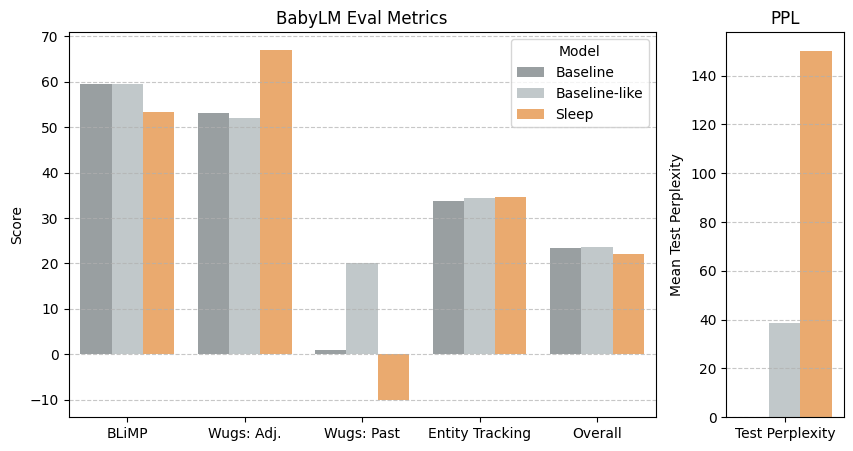

In [95]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5),
                       width_ratios=[5, 1])
sns.barplot(eval_results[eval_results['task'] != 'Test Perplexity'].sort_values('run'), 
            x='task', y='score', hue='run', 
            palette=model_cmap, ax=axs[0])
axs[0].legend(title="Model")
axs[0].set_title("BabyLM Eval Metrics")
axs[0].set_ylabel("Score")
axs[0].set_xlabel("")
axs[0].set_xticks(ticks=babylm_tasks, labels=babylm_tasks_formatted)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(eval_results[eval_results['task'] == 'Test Perplexity'].sort_values('run'), 
            x='task', y='score', hue='run', 
            palette=model_cmap, ax=axs[1])
axs[1].set_title("PPL")
axs[1].get_legend().remove()
axs[1].set_ylabel("Mean Test Perplexity")
axs[1].set_xlabel("")
axs[1].grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("plots/babylm_eval.png", 
            bbox_inches='tight', dpi=300,
            transparent=True)